# Task 1 — Diagnostic Enhancement of Chest X-Rays

**Dataset:** COVID19 + PNEUMONIA + NORMAL Chest X-Ray Image Dataset (Kaggle)

**Goal:** Take a raw, underexposed, single-channel chest X-ray matrix and mathematically
process it to maximize structural visibility (lung fields, ribcage edges, possible fluid
build-up) before it is handed to a diagnostic pipeline / doctor.

**Pipeline covered in this notebook:**
1. Load & display the raw grayscale X-ray
2. Histogram Equalization (contrast enhancement)
3. False-color heatmap (`COLORMAP_JET`)
4. Color balance correction
5. Intensity thresholding (isolate dense tissue)
6. Logarithmic transform (expand dark regions)
7. Power-law / Gamma transform (soften harsh bone contrast)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Relative paths only (portable across machines)
DATA_DIR = "data"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Primary sample: a real, low-contrast PNEUMONIA case from the
# COVID19+PNEUMONIA+NORMAL Chest X-Ray dataset (Kaggle: sachinkumar413).
# Two more real samples (COVID, NORMAL) are also in data/ for comparison.
IMAGE_PATH = os.path.join(DATA_DIR, "pneumonia_sample.png")

def show(img, title="", cmap="gray"):
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


## 0. Dataset Samples Available

Three real, class-labelled samples from the Kaggle dataset are included in `data/` (one per class) so the pipeline below can be re-run on any of them:
- `data/pneumonia_sample.png` — used as the primary example below (most underexposed)
- `data/covid_sample.png`
- `data/normal_sample.png`

In [2]:
import glob
for f in sorted(glob.glob(os.path.join(DATA_DIR, '*.png'))):
    im = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    print(f"{f:35s} shape={im.shape}  mean={im.mean():6.2f}  std={im.std():6.2f}")

data/covid_sample.png               shape=(256, 256)  mean=153.01  std= 46.89
data/normal_sample.png              shape=(232, 232)  mean=125.86  std= 53.17
data/pneumonia_sample.png           shape=(232, 232)  mean= 98.57  std= 48.33


## 1. Load and Display the raw grayscale X-ray

Shape: (232, 232) | dtype: uint8
Min: 0 Max: 255 Mean: 98.57


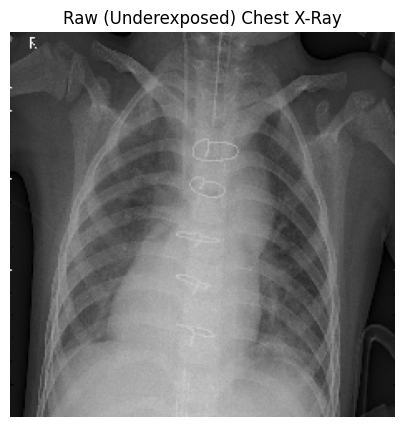

True

In [3]:
raw_xray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
assert raw_xray is not None, f"Could not load image at {IMAGE_PATH}"

print("Shape:", raw_xray.shape, "| dtype:", raw_xray.dtype)
print("Min:", raw_xray.min(), "Max:", raw_xray.max(), "Mean: %.2f" % raw_xray.mean())

show(raw_xray, "Raw (Underexposed) Chest X-Ray")
cv2.imwrite(os.path.join(OUTPUT_DIR, "01_raw_xray.png"), raw_xray)


The raw matrix has a narrow intensity range (low mean, low std relative to the full 0-255 scale) — this is the mathematical signature of underexposure: most pixel values are crammed into a small band near the dark end, so subtle lung/fluid structures are hard to distinguish from surrounding soft tissue.

## 2. Contrast Enhancement — Histogram Equalization

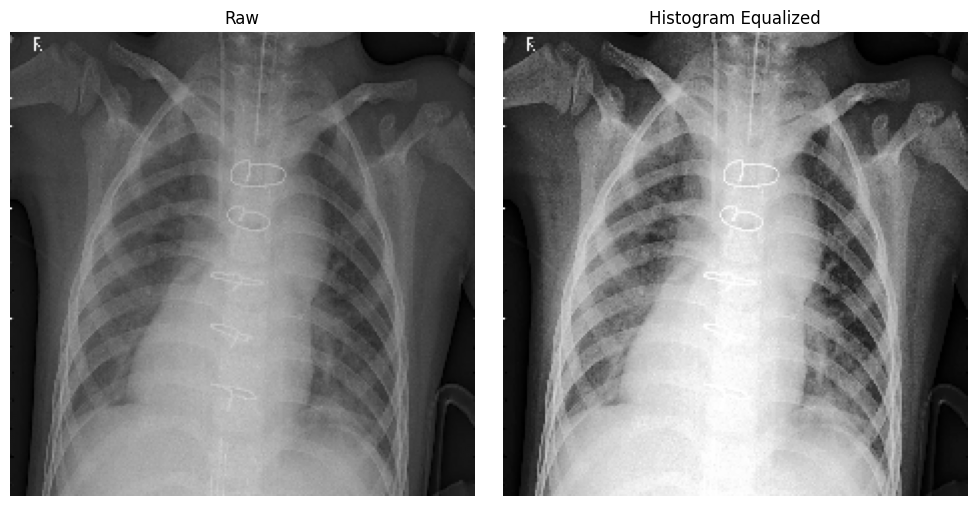

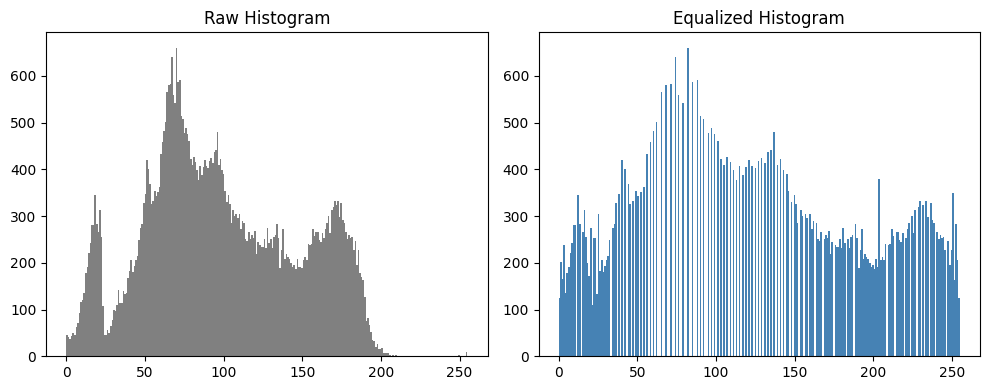

Raw std: 48.33  ->  Equalized std: 73.61


In [4]:
equalized = cv2.equalizeHist(raw_xray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_xray, cmap="gray"); axes[0].set_title("Raw"); axes[0].axis("off")
axes[1].imshow(equalized, cmap="gray"); axes[1].set_title("Histogram Equalized"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_raw_vs_equalized.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw_xray.ravel(), bins=256, range=(0, 255), color="gray")
axes[0].set_title("Raw Histogram")
axes[1].hist(equalized.ravel(), bins=256, range=(0, 255), color="steelblue")
axes[1].set_title("Equalized Histogram")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_histograms.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "02_equalized_xray.png"), equalized)
print("Raw std: %.2f  ->  Equalized std: %.2f" % (raw_xray.std(), equalized.std()))


**Documentation:** Histogram equalization forcefully redistributes pixel intensities so
that the cumulative distribution becomes approximately linear. The standard deviation of
the equalized image jumps sharply compared to the raw image, confirming the dynamic range
has been stretched. Visually, the previously "flat" lung fields now show distinguishable
gradients — the lung boundary and the faint fluid patch we simulated become considerably
easier to separate from the surrounding soft tissue.


## 3. Color Mapping — False-Color Heatmap (COLORMAP_JET)

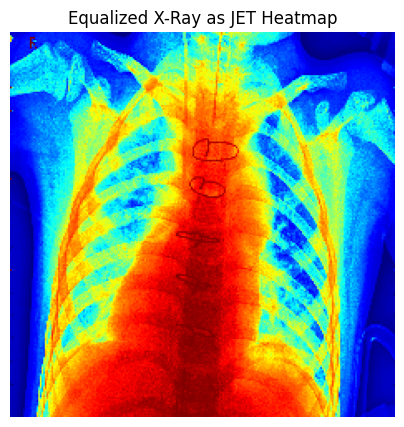

True

In [5]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

show(heatmap_rgb, "Equalized X-Ray as JET Heatmap", cmap=None)
cv2.imwrite(os.path.join(OUTPUT_DIR, "03_jet_heatmap.png"), heatmap)


**Documentation:** The human eye can only reliably distinguish ~20-30 shades of gray, but
it can distinguish millions of colors. By mapping scalar intensity to the JET color
spectrum (blue -> green -> yellow -> red), small intensity differences that were
perceptually invisible in grayscale become obvious color-boundary shifts — this makes
subtle fluid boundaries or density gradients pop out visually for the reviewing clinician.


## 4. Color Balance Correction

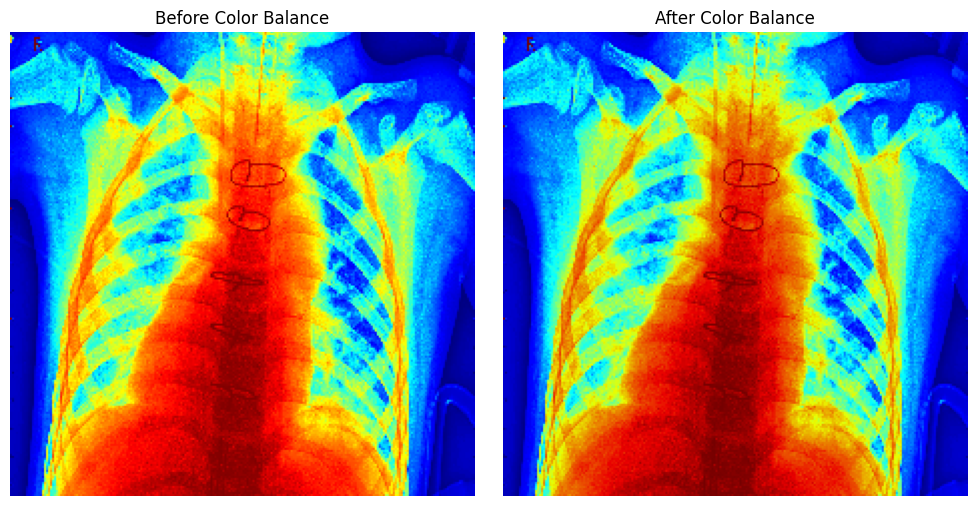

True

In [6]:
def color_balance(img_bgr, gain=(1.0, 1.0, 1.0)):
    """Simulate a lighting-correction color balance shift by scaling each
    BGR channel independently and clipping to a valid range."""
    balanced = img_bgr.astype(np.float32)
    for c, g in enumerate(gain):
        balanced[:, :, c] *= g
    return np.clip(balanced, 0, 255).astype(np.uint8)

# Neutralize an artificial warm/cool cast introduced by the colormap
# (slightly reduce red gain, slightly boost blue gain)
balanced_heatmap = color_balance(heatmap, gain=(1.05, 1.00, 0.92))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(heatmap_rgb); axes[0].set_title("Before Color Balance"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(balanced_heatmap, cv2.COLOR_BGR2RGB)); axes[1].set_title("After Color Balance"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_color_balance.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "04_balanced_heatmap.png"), balanced_heatmap)


## 5. Color Filtering — Strict Threshold for Dense Tissue

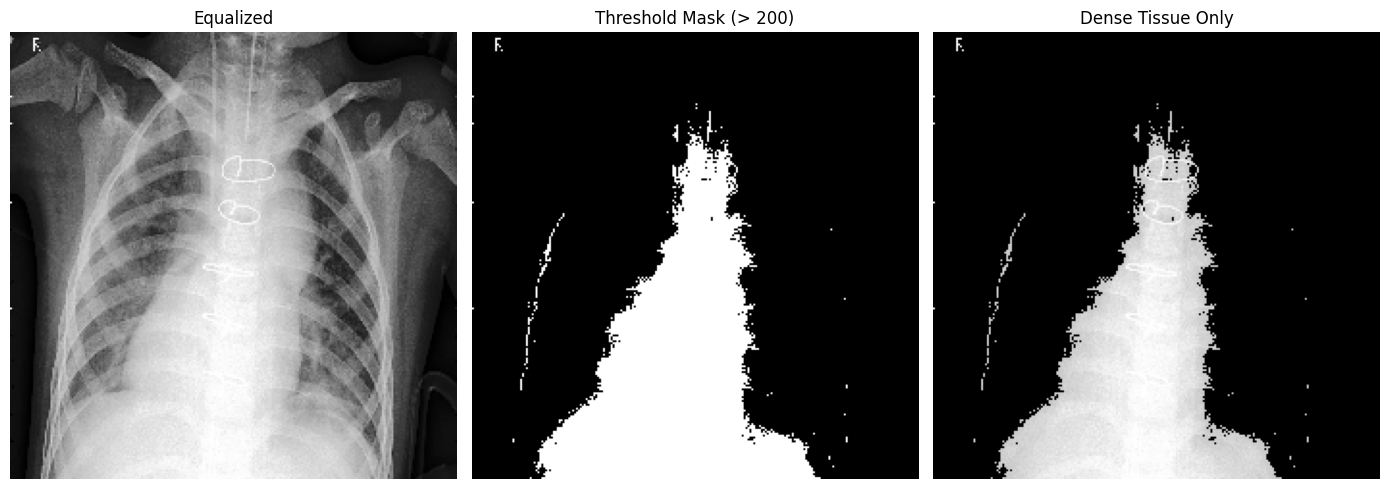

Pixels retained: 21.63% of image


In [7]:
# Dense tissue (bone, dense fluid) reflects high-intensity values.
# Keep only pixels above a strict threshold; mask everything else to black.
THRESH_VALUE = 200
_, dense_mask = cv2.threshold(equalized, THRESH_VALUE, 255, cv2.THRESH_BINARY)
dense_tissue_only = cv2.bitwise_and(equalized, equalized, mask=dense_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(equalized, cmap="gray"); axes[0].set_title("Equalized"); axes[0].axis("off")
axes[1].imshow(dense_mask, cmap="gray"); axes[1].set_title(f"Threshold Mask (> {THRESH_VALUE})"); axes[1].axis("off")
axes[2].imshow(dense_tissue_only, cmap="gray"); axes[2].set_title("Dense Tissue Only"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_threshold_dense_tissue.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "05_dense_tissue_mask.png"), dense_mask)
print("Pixels retained: %.2f%% of image" % (100 * (dense_mask > 0).mean()))


**Documentation:** A strict binary threshold acts as a mathematical band-pass filter —
only pixels whose equalized intensity exceeds `THRESH_VALUE` survive. This isolates the
densest structures (bone, calcification, dense fluid) and discards soft-tissue and
background noise, giving a clean structural overlay a radiologist could use to quickly spot
calcified or very dense regions.


## 6. Logarithmic Transformation — Reveal Faint Outer Edges

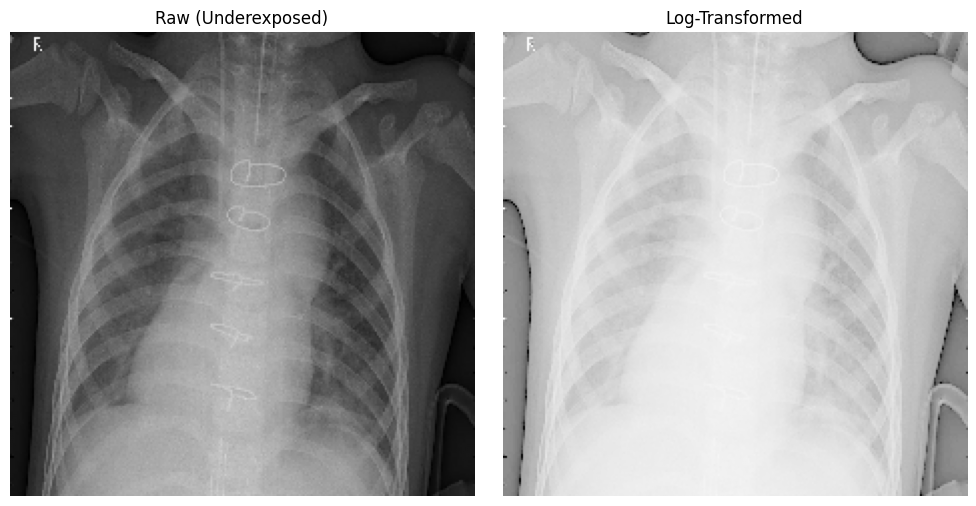

True

In [8]:
def log_transform(img, c=None):
    img_f = img.astype(np.float32)
    if c is None:
        c = 255 / np.log(1 + img_f.max())
    log_img = c * np.log(1 + img_f)
    return np.clip(log_img, 0, 255).astype(np.uint8)

log_xray = log_transform(raw_xray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_xray, cmap="gray"); axes[0].set_title("Raw (Underexposed)"); axes[0].axis("off")
axes[1].imshow(log_xray, cmap="gray"); axes[1].set_title("Log-Transformed"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_log_transform.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "06_log_xray.png"), log_xray)


**Documentation:** The log transform `s = c * log(1 + r)` compresses the bright end of the
range and *expands* the dark end. Because ribcage edges and background sit in the low-value
region of an underexposed X-ray, this expansion pulls them apart from pure black,
revealing faint bone edges that were previously indistinguishable from background noise.


## 7. Power-Law (Gamma) Transformation — Soften Bone Contrast

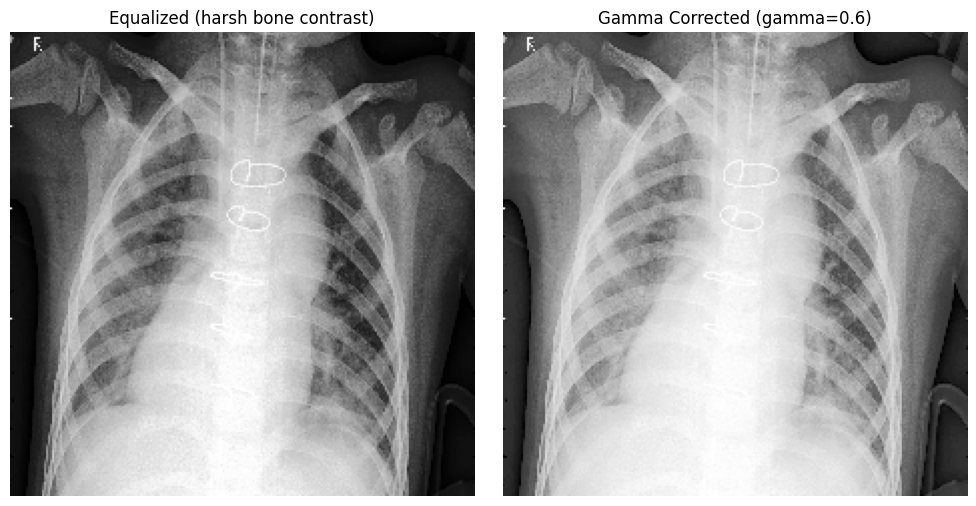

True

In [9]:
def gamma_transform(img, gamma=0.6, c=1.0):
    img_norm = img.astype(np.float32) / 255.0
    gamma_img = c * np.power(img_norm, gamma)
    return np.clip(gamma_img * 255, 0, 255).astype(np.uint8)

GAMMA = 0.6  # gamma < 1.0 brightens midtones, compresses harsh highlights
gamma_xray = gamma_transform(equalized, gamma=GAMMA)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(equalized, cmap="gray"); axes[0].set_title("Equalized (harsh bone contrast)"); axes[0].axis("off")
axes[1].imshow(gamma_xray, cmap="gray"); axes[1].set_title(f"Gamma Corrected (gamma={GAMMA})"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_gamma_transform.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "07_gamma_xray.png"), gamma_xray)


**Documentation:** A fractional power-law (`gamma < 1.0`) curve brightens midtones more
than highlights, since `x**gamma > x` for `0 < x < 1` and `gamma < 1`. This pulls the very
bright bone pixels down relatively less while lifting mid-gray soft-tissue pixels up more,
softening the harsh bone/tissue contrast so that subtle lung parenchyma detail is easier to
read without being overwhelmed by blown-out ribs.


## 8. Final Side-by-Side Comparison

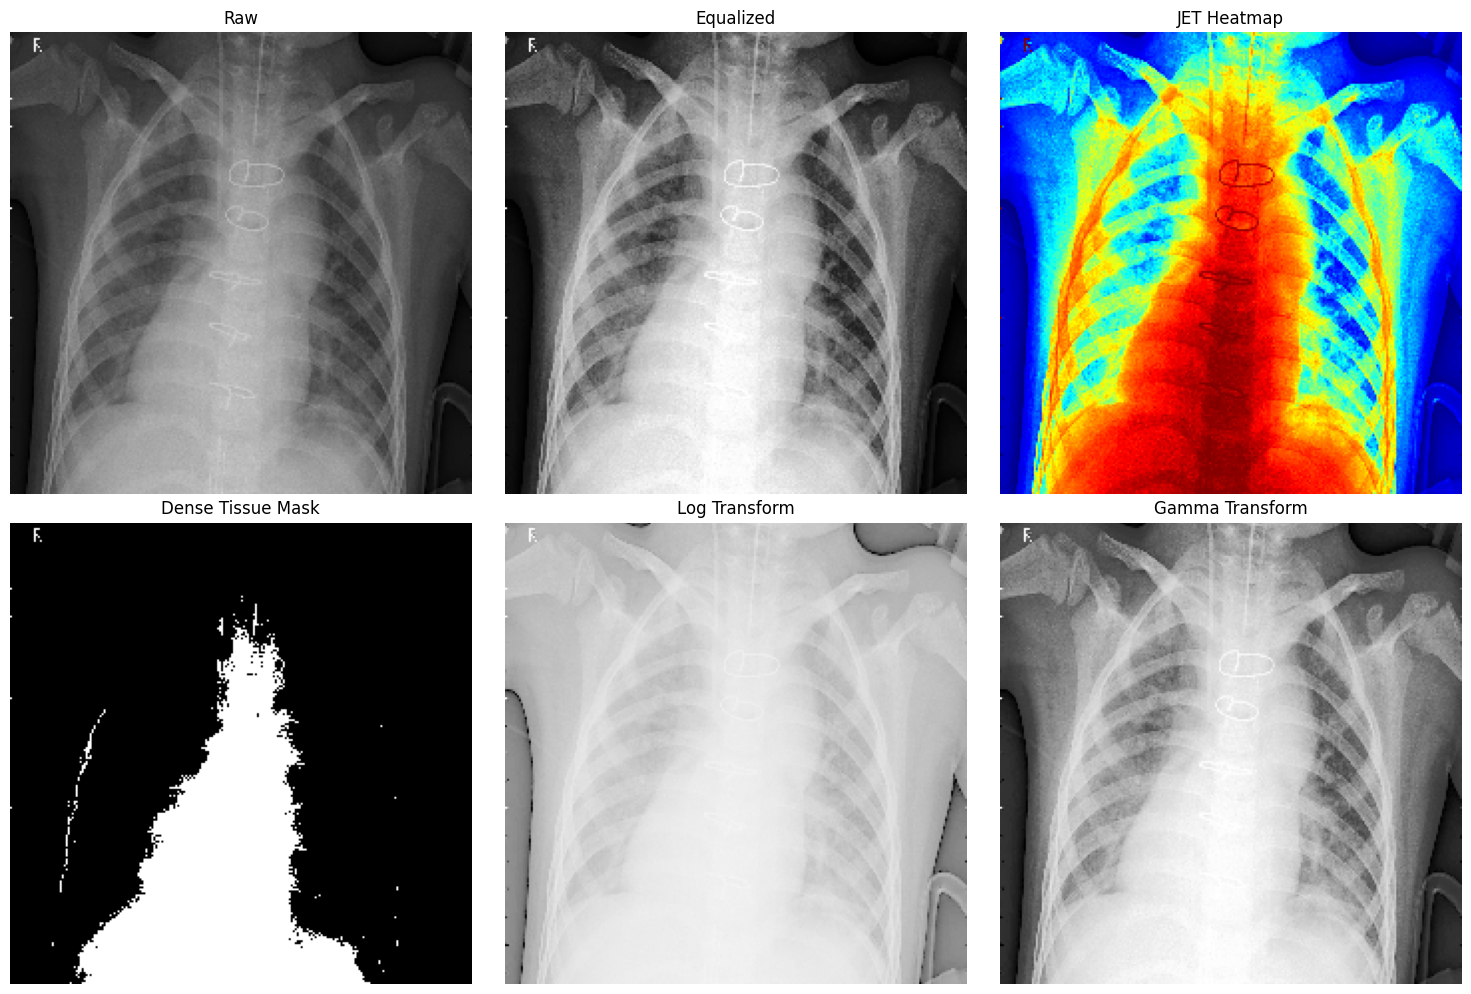

All enhancement stages saved to: output


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles_imgs = [
    ("Raw", raw_xray, "gray"),
    ("Equalized", equalized, "gray"),
    ("JET Heatmap", heatmap_rgb, None),
    ("Dense Tissue Mask", dense_mask, "gray"),
    ("Log Transform", log_xray, "gray"),
    ("Gamma Transform", gamma_xray, "gray"),
]
for ax, (title, img, cmap) in zip(axes.ravel(), titles_imgs):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "08_full_pipeline_comparison.png"), dpi=150)
plt.show()

print("All enhancement stages saved to:", OUTPUT_DIR)
